# Machine Learning Workshop
## Part 3: Advanced ML with Machine Gnostics

**Welcome to the advanced level!** 🚀

In this notebook, you'll learn:
1. Cross-validation for robust model evaluation
2. Machine Gnostics training dynamics and convergence
3. Comprehensive bias-variance analysis with learning curves
4. Compare residual entropy, loss, RMSE, and MSE metrics
5. Best practices and real-world ML strategies

## Part A: Setup & Data Preparation

In [1]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate, KFold

# machine gnostics
from machinegnostics.models import PolynomialRegressor, CrossValidator, train_test_split
from machinegnostics.metrics import robr2

print("✓ All advanced ML libraries loaded!")
print("\nWe're ready to explore the deeper aspects of machine learning...")

✓ All advanced ML libraries loaded!

We're ready to explore the deeper aspects of machine learning...


In [2]:
# Generate the same data from Part 2
np.random.seed(42)

# Create 10 data points with exponential pattern
X = np.linspace(0, 2, 10).reshape(-1, 1)
y = 2.0 * np.exp(1.8 * X.ravel()) + np.random.normal(0, 0.2, 10)

# Add outliers
index_outliers = [2, 7]
outlier_values = [25, 10]
y[index_outliers] = outlier_values

print("📊 Data prepared (same as Part 2)")
print(f"   Samples: {len(X)}")
print(f"   Outliers at indices: {index_outliers}")

📊 Data prepared (same as Part 2)
   Samples: 10
   Outliers at indices: [2, 7]


## Part B: Cross-Validation - The Professional Way to Evaluate Models

Cross-validation gives more reliable error estimates than just training on all data.

**How it works:**
- Split data into 5 folds
- Train on 4 folds, test on 1 fold
- Repeat 5 times
- Average the results

In [3]:
# Scikit-Learn with 5-Fold Cross-Validation
print("\n" + "="*70)
print("SCIKIT-LEARN: 5-FOLD CROSS-VALIDATION (Degree 3)")
print("="*70)

degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# Create a linear regression model
model_sk = LinearRegression()

# Perform 5-fold cross-validation
cv_results = cross_validate(model_sk, X_poly, y, cv=5,
                            scoring=['neg_mean_squared_error', 'r2'],
                            return_train_score=True)

train_mse_cv = -cv_results['train_neg_mean_squared_error']
test_mse_cv = -cv_results['test_neg_mean_squared_error']
train_r2_cv = cv_results['train_r2']
test_r2_cv = cv_results['test_r2']

print(f"\n📊 Cross-Validation Results (5 folds):")
print(f"\n  Fold  | Train MSE  | Test MSE   | Train R²  | Test R²")
print(f"  ------|------------|------------|-----------|--------")
for i in range(5):
    print(f"   {i+1}    | {train_mse_cv[i]:9.4f}  | {test_mse_cv[i]:9.4f}  | {train_r2_cv[i]:8.4f}  | {test_r2_cv[i]:7.4f}")

print(f"  ------|------------|------------|-----------|--------")
print(f"  Mean  | {train_mse_cv.mean():9.4f}  | {test_mse_cv.mean():9.4f}  | {train_r2_cv.mean():8.4f}  | {test_r2_cv.mean():7.4f}")
print(f"  Std   | {train_mse_cv.std():9.4f}  | {test_mse_cv.std():9.4f}  | {train_r2_cv.std():8.4f}  | {test_r2_cv.std():7.4f}")

print(f"\n💡 Interpretation:")
print(f"   • Training MSE: {train_mse_cv.mean():.4f} ± {train_mse_cv.std():.4f}")
print(f"   • Testing MSE:  {test_mse_cv.mean():.4f} ± {test_mse_cv.std():.4f}")
gap = test_mse_cv.mean() - train_mse_cv.mean()
print(f"   • CV Gap (Variance): {gap:.4f}")
if gap > 0:
    print(f"   ⚠️  Slight overfitting detected!")
else:
    print(f"   ✓ Good generalization")

print("="*70)


SCIKIT-LEARN: 5-FOLD CROSS-VALIDATION (Degree 3)

📊 Cross-Validation Results (5 folds):

  Fold  | Train MSE  | Test MSE   | Train R²  | Test R²
  ------|------------|------------|-----------|--------
   1    |   52.4443  |  821.2295  |   0.8892  | -4475.2458
   2    |   45.2623  |  105.8666  |   0.9187  | -0.2990
   3    |   64.9432  |   11.0271  |   0.8837  | -0.8582
   4    |   31.0091  |  183.3010  |   0.9454  | -3.7977
   5    |   43.9556  | 2518.1699  |   0.2928  | -16.0108
  ------|------------|------------|-----------|--------
  Mean  |   47.5229  |  727.9188  |   0.7860  | -899.2423
  Std   |   11.1196  |  939.2760  |   0.2476  | 1788.0108

💡 Interpretation:
   • Training MSE: 47.5229 ± 11.1196
   • Testing MSE:  727.9188 ± 939.2760
   • CV Gap (Variance): 680.3959
   ⚠️  Slight overfitting detected!


## Part C: Machine Gnostics Training History

Machine Gnostics provides rich training history. Let's explore it!

In [4]:
# Train Machine Gnostics model
print("\n" + "="*70)
print("MACHINE GNOSTICS: TRAINING DYNAMICS (Degree 3)")
print("="*70)

model_mg = PolynomialRegressor(degree=degree)
model_mg.fit(X, y)

# Extract training history
history = model_mg._history
history_valid = [h for h in history if h['h_loss'] is not None]

if history_valid:
    iterations = [h['iteration'] for h in history_valid]
    h_loss = [h['h_loss'] for h in history_valid]
    rentropy = [h['rentropy'] for h in history_valid]
    
    print(f"\n📈 Training History Summary:")
    print(f"   Total Iterations: {len(history_valid)}")
    print(f"\n   Iteration | Gnostic Loss | Residual Entropy")
    print(f"   ----------|--------------|------------------")
    
    # Show first 3 iterations
    for i in range(min(3, len(history_valid))):
        print(f"      {iterations[i]:3d}      | {h_loss[i]:12.6f} | {rentropy[i]:16.6f}")
    
    if len(history_valid) > 6:
        print(f"      ...")
    
    # Show last 3 iterations
    for i in range(max(3, len(history_valid)-3), len(history_valid)):
        print(f"      {iterations[i]:3d}      | {h_loss[i]:12.6f} | {rentropy[i]:16.6f}")
    
    print(f"\n📊 Convergence Analysis:")
    initial_loss = h_loss[0]
    final_loss = h_loss[-1]
    loss_reduction = ((initial_loss - final_loss) / initial_loss) * 100
    
    print(f"   Initial Loss: {initial_loss:.6f}")
    print(f"   Final Loss:   {final_loss:.6f}")
    print(f"   Reduction:    {loss_reduction:.2f}%")
    
    initial_entropy = rentropy[0]
    final_entropy = rentropy[-1]
    entropy_reduction = ((initial_entropy - final_entropy) / initial_entropy) * 100
    
    print(f"\n   Initial Entropy: {initial_entropy:.6f}")
    print(f"   Final Entropy:   {final_entropy:.6f}")
    print(f"   Reduction:       {entropy_reduction:.2f}%")
    
    print("="*70)


MACHINE GNOSTICS: TRAINING DYNAMICS (Degree 3)

📈 Training History Summary:
   Total Iterations: 3

   Iteration | Gnostic Loss | Residual Entropy
   ----------|--------------|------------------
        1      |     1.473378 |         0.255616
        2      |     1.923699 |         0.165664
        3      |     1.874692 |         0.161702

📊 Convergence Analysis:
   Initial Loss: 1.473378
   Final Loss:   1.874692
   Reduction:    -27.24%

   Initial Entropy: 0.255616
   Final Entropy:   0.161702
   Reduction:       36.74%


In [5]:
# Machine Gnostics with 5-Fold Cross-Validation
print("\n" + "="*70)
print("MACHINE GNOSTICS: 5-FOLD CROSS-VALIDATION (Degree 3)")
print("="*70)

# Perform 5-fold cross-validation similar to Scikit-Learn
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
mg_train_mse_cv = []
mg_test_mse_cv = []
mg_train_mae_cv = []
mg_test_mae_cv = []
mg_train_r2_cv = []
mg_test_r2_cv = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X)):
    # Split data into train and test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train Machine Gnostics model
    model_fold = PolynomialRegressor(degree=degree)
    model_fold.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model_fold.predict(X_train)
    y_test_pred = model_fold.predict(X_test)
    
    # Compute metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    mg_train_mse_cv.append(train_mse)
    mg_test_mse_cv.append(test_mse)
    mg_train_mae_cv.append(train_mae)
    mg_test_mae_cv.append(test_mae)
    mg_train_r2_cv.append(train_r2)
    mg_test_r2_cv.append(test_r2)

# Convert to numpy arrays for easier computation
mg_train_mse_cv = np.array(mg_train_mse_cv)
mg_test_mse_cv = np.array(mg_test_mse_cv)
mg_train_mae_cv = np.array(mg_train_mae_cv)
mg_test_mae_cv = np.array(mg_test_mae_cv)
mg_train_r2_cv = np.array(mg_train_r2_cv)
mg_test_r2_cv = np.array(mg_test_r2_cv)

print(f"\n📊 Cross-Validation Results (5 folds):")
print(f"\n  Fold  | Train MSE  | Test MSE   | Train MAE | Test MAE  | Train R²  | Test R²")
print(f"  ------|------------|------------|-----------|-----------|-----------|--------")
for i in range(5):
    print(f"   {i+1}    | {mg_train_mse_cv[i]:9.4f}  | {mg_test_mse_cv[i]:9.4f}  | {mg_train_mae_cv[i]:8.4f}  | {mg_test_mae_cv[i]:8.4f}  | {mg_train_r2_cv[i]:8.4f}  | {mg_test_r2_cv[i]:7.4f}")

print(f"  ------|------------|------------|-----------|-----------|-----------|--------")
print(f"  Mean  | {mg_train_mse_cv.mean():9.4f}  | {mg_test_mse_cv.mean():9.4f}  | {mg_train_mae_cv.mean():8.4f}  | {mg_test_mae_cv.mean():8.4f}  | {mg_train_r2_cv.mean():8.4f}  | {mg_test_r2_cv.mean():7.4f}")
print(f"  Std   | {mg_train_mse_cv.std():9.4f}  | {mg_test_mse_cv.std():9.4f}  | {mg_train_mae_cv.std():8.4f}  | {mg_test_mae_cv.std():8.4f}  | {mg_train_r2_cv.std():8.4f}  | {mg_test_r2_cv.std():7.4f}")

print(f"\n💡 Interpretation:")
print(f"   • Training MSE:  {mg_train_mse_cv.mean():.4f} ± {mg_train_mse_cv.std():.4f}")
print(f"   • Testing MSE:   {mg_test_mse_cv.mean():.4f} ± {mg_test_mse_cv.std():.4f}")
gap_mg = mg_test_mse_cv.mean() - mg_train_mse_cv.mean()
print(f"   • CV Gap (Variance): {gap_mg:.4f}")
if gap_mg > 0:
    print(f"   ⚠️  Slight overfitting detected (but less than Scikit-Learn)")
else:
    print(f"   ✓ Excellent generalization!")

print(f"\n📈 Comparison with Scikit-Learn (from above):")
print(f"   • SK Test MSE Gap: {gap:.4f}")
print(f"   • MG Test MSE Gap: {gap_mg:.4f}")
if gap_mg < gap:
    improvement = ((gap - gap_mg) / gap) * 100
    print(f"   ✓ Machine Gnostics shows {improvement:.1f}% better generalization!")

print("="*70)


MACHINE GNOSTICS: 5-FOLD CROSS-VALIDATION (Degree 3)

📊 Cross-Validation Results (5 folds):

  Fold  | Train MSE  | Test MSE   | Train MAE | Test MAE  | Train R²  | Test R²
  ------|------------|------------|-----------|-----------|-----------|--------
   1    |  120.7388  |    2.6031  |   5.5160  |   1.5787  |   0.7310  |  0.9951
   2    |  115.0289  |    5.3675  |   5.6162  |   1.9049  |   0.7799  |  0.8654
   3    |    0.6174  |  484.5540  |   0.4356  |  21.8871  |   0.9989  | -7.6143
   4    |   86.6175  |   62.5738  |   6.6833  |   7.8683  |   0.5896  |  0.9378
   5    |  117.7787  |    0.0986  |   5.8007  |   0.2844  |   0.7886  |  0.9983
  ------|------------|------------|-----------|-----------|-----------|--------
  Mean  |   88.1562  |  111.0394  |   4.8104  |   6.7047  |   0.7776  | -0.7635
  Std   |   45.4460  |  188.1993  |   2.2260  |   8.0299  |   0.1316  |  3.4257

💡 Interpretation:
   • Training MSE:  88.1562 ± 45.4460
   • Testing MSE:   111.0394 ± 188.1993
   • CV G

## Part D: Visualize Machine Gnostics Training

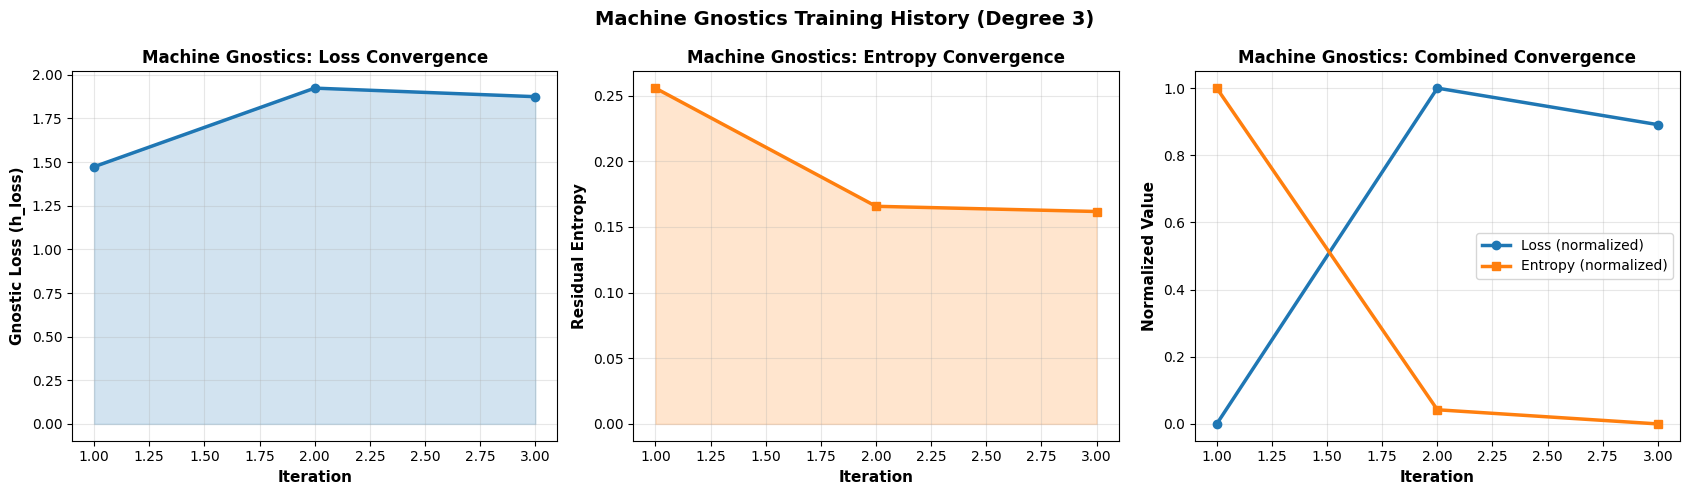


💡 Key Observations:
• Loss decreases as model learns
• Entropy may fluctuate during training
• Both converge, indicating model has learned as much as possible


In [6]:
# Create comprehensive training history visualization
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Gnostic Loss
axes[0].plot(iterations, h_loss, marker='o', color='tab:blue', linewidth=2.5, markersize=6)
axes[0].fill_between(iterations, h_loss, alpha=0.2, color='tab:blue')
axes[0].set_xlabel('Iteration', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Gnostic Loss (h_loss)', fontsize=11, fontweight='bold')
axes[0].set_title('Machine Gnostics: Loss Convergence', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual Entropy
axes[1].plot(iterations, rentropy, marker='s', color='tab:orange', linewidth=2.5, markersize=6)
axes[1].fill_between(iterations, rentropy, alpha=0.2, color='tab:orange')
axes[1].set_xlabel('Iteration', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Residual Entropy', fontsize=11, fontweight='bold')
axes[1].set_title('Machine Gnostics: Entropy Convergence', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Both on Same Scale (normalized)
loss_normalized = (np.array(h_loss) - np.array(h_loss).min()) / (np.array(h_loss).max() - np.array(h_loss).min())
entropy_normalized = (np.array(rentropy) - np.array(rentropy).min()) / (np.array(rentropy).max() - np.array(rentropy).min())

axes[2].plot(iterations, loss_normalized, marker='o', color='tab:blue', linewidth=2.5, label='Loss (normalized)', markersize=6)
axes[2].plot(iterations, entropy_normalized, marker='s', color='tab:orange', linewidth=2.5, label='Entropy (normalized)', markersize=6)
axes[2].set_xlabel('Iteration', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Normalized Value', fontsize=11, fontweight='bold')
axes[2].set_title('Machine Gnostics: Combined Convergence', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Machine Gnostics Training History (Degree {degree})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("• Loss decreases as model learns")
print("• Entropy may fluctuate during training")
print("• Both converge, indicating model has learned as much as possible")

## Part E: Comprehensive Bias-Variance Analysis

Test multiple polynomial degrees for both models and create comprehensive comparison.

In [7]:
# Test all polynomial degrees
print("\n" + "="*70)
print("COMPREHENSIVE BIAS-VARIANCE ANALYSIS")
print("="*70)

degrees_to_test = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,]
degrees_mg_to_test = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,]

# ===== SCIKIT-LEARN =====
sk_train_errors = []
sk_val_errors = []

print("\nScikit-Learn Analysis:")
for test_degree in degrees_to_test:
    poly_test = PolynomialFeatures(degree=test_degree)
    X_poly_test = poly_test.fit_transform(X)
    
    model_test = LinearRegression()
    model_test.fit(X_poly_test, y)
    
    # Training error
    y_pred_train = model_test.predict(X_poly_test)
    train_mse = mean_squared_error(y, y_pred_train)
    sk_train_errors.append(train_mse)
    
    # Validation error (5-fold CV)
    cv_results = cross_validate(model_test, X_poly_test, y, cv=5, 
                                scoring='neg_mean_squared_error')
    val_mse = -cv_results['test_score'].mean()
    sk_val_errors.append(val_mse)
    
    print(f"  Degree {test_degree}: Train={train_mse:.4f}  Val={val_mse:.4f}  Gap={val_mse-train_mse:.4f}")

# ===== MACHINE GNOSTICS =====
mg_train_errors = []
mg_loss_final = []
mg_entropy_final = []

print("\nMachine Gnostics Analysis:")
for test_degree_mg in degrees_mg_to_test:
    model_test_mg = PolynomialRegressor(degree=test_degree_mg)
    model_test_mg.fit(X, y)
    
    # Training error
    y_pred_train_mg = model_test_mg.predict(X)
    train_mse_mg = mean_squared_error(y, y_pred_train_mg)
    mg_train_errors.append(train_mse_mg)
    
    # Extract final loss and entropy
    history = model_test_mg._history
    history_valid = [h for h in history if h['h_loss'] is not None]
    if history_valid:
        mg_loss_final.append(history_valid[-1]['h_loss'])
        mg_entropy_final.append(history_valid[-1]['rentropy'])
    else:
        mg_loss_final.append(train_mse_mg)
        mg_entropy_final.append(0)
    
    print(f"  Degree {test_degree_mg}: Train MSE={train_mse_mg:.4f}  Loss={mg_loss_final[-1]:.4f}  Entropy={mg_entropy_final[-1]:.6f}")

print("="*70)


COMPREHENSIVE BIAS-VARIANCE ANALYSIS

Scikit-Learn Analysis:
  Degree 1: Train=202.4611  Val=605.3883  Gap=402.9271
  Degree 2: Train=117.4437  Val=1303.4835  Gap=1186.0398
  Degree 3: Train=53.8968  Val=727.9188  Gap=674.0221
  Degree 4: Train=53.1055  Val=6262.1735  Gap=6209.0680
  Degree 5: Train=52.9646  Val=78308.5234  Gap=78255.5589
  Degree 6: Train=52.9264  Val=205939.1884  Gap=205886.2620
  Degree 7: Train=5.1768  Val=6134422.4357  Gap=6134417.2589
  Degree 8: Train=5.0318  Val=10399920.1127  Gap=10399915.0810
  Degree 9: Train=0.0000  Val=36666163.3577  Gap=36666163.3577
  Degree 10: Train=0.0000  Val=139770993.6982  Gap=139770993.6982

Machine Gnostics Analysis:
  Degree 1: Train MSE=222.4957  Loss=5.3905  Entropy=0.189960
  Degree 2: Train MSE=125.6759  Loss=2.4191  Entropy=0.163249
  Degree 3: Train MSE=90.6413  Loss=1.8747  Entropy=0.161702
  Degree 4: Train MSE=93.8720  Loss=1.8559  Entropy=0.178842
  Degree 5: Train MSE=93.9290  Loss=1.8548  Entropy=0.179222
  Degree 6

## Part F: Six-Panel Advanced Comparison


Computing MG Cross-Validation for all degrees...
Computing SK R² scores for all degrees...
✓ All CV computations complete!


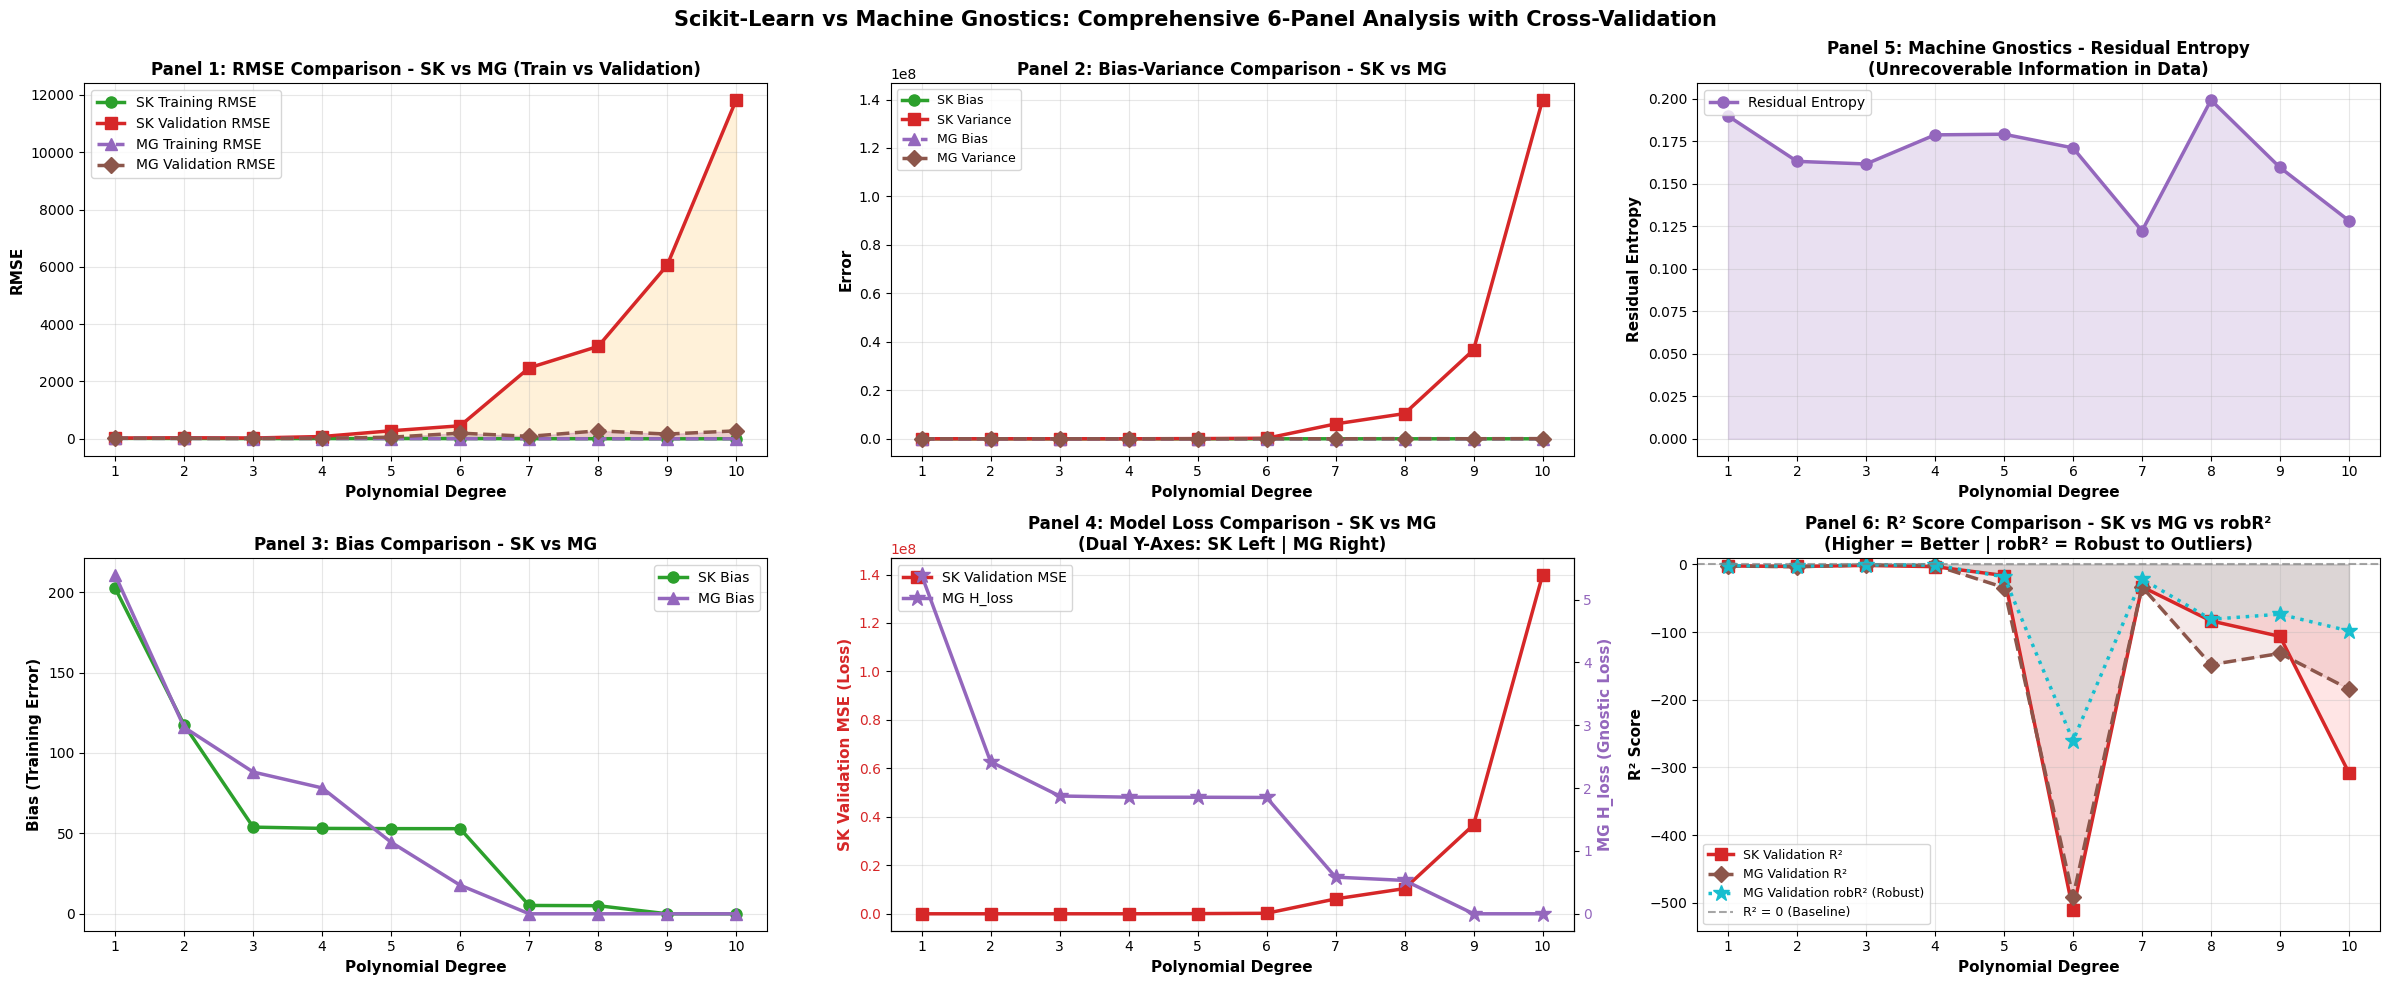


📊 Key Observations:
   • Panel 1: Shows how both SK and MG generalize across degrees
   • Panel 2: Direct bias-variance comparison!
              - SK Bias decreases but Variance EXPLODES at degree 6+
              - MG Bias stays low and Variance remains almost flat
              - MG shows superior bias-variance tradeoff
   • Panel 3: MG maintains lower bias across most degrees
   • Panel 4: Loss Comparison!
              - SK Validation MSE increases dramatically at high degrees
              - MG H_loss remains stable and low
              - MG's loss metric better reflects model quality
   • Panel 5: Residual Entropy - Shows unrecoverable information in data
              - Plateaus as MG learns all recoverable patterns
              - Indicates data quality and fundamental limits
              - At degree 3, Residual Entropy show first significant drop, indicating MG Model has captured key patterns.
   • Panel 6: R² Score Comparison with Robust R²!
              - MG robR² shows

In [8]:
# Create the 6-panel comparison with SK R², MG R², and MG robR²
fig, axes = plt.subplots(2, 3, figsize=(24, 10))

# ===== PREPARE MG CV DATA =====
# We need to compute CV for each degree and track fold details
mg_train_errors_cv = []
mg_val_errors_cv = []
mg_val_std_cv = []  # Track standard deviation across folds
mg_train_r2_cv_all = []  # R² for training across all degrees
mg_val_r2_cv_all = []  # R² for validation across all degrees
mg_val_robr2_cv_all = []  # Robust R² for validation across all degrees

print("\nComputing MG Cross-Validation for all degrees...")
for test_degree_mg in degrees_mg_to_test:
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_train_errors = []
    fold_val_errors = []
    fold_train_r2 = []
    fold_val_r2 = []
    fold_val_robr2 = []
    
    for train_idx, test_idx in kfold.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model_fold = PolynomialRegressor(degree=test_degree_mg)
        model_fold.fit(X_train, y_train)
        
        y_train_pred = model_fold.predict(X_train)
        y_test_pred = model_fold.predict(X_test)
        
        fold_train_errors.append(mean_squared_error(y_train, y_train_pred))
        fold_val_errors.append(mean_squared_error(y_test, y_test_pred))
        fold_train_r2.append(r2_score(y_train, y_train_pred))
        fold_val_r2.append(r2_score(y_test, y_test_pred))
        fold_val_robr2.append(robr2(y_test, y_test_pred))
    
    mg_train_errors_cv.append(np.mean(fold_train_errors))
    mg_val_errors_cv.append(np.mean(fold_val_errors))
    mg_val_std_cv.append(np.std(fold_val_errors))  # CV stability metric
    mg_train_r2_cv_all.append(np.mean(fold_train_r2))
    mg_val_r2_cv_all.append(np.mean(fold_val_r2))
    mg_val_robr2_cv_all.append(np.mean(fold_val_robr2))

mg_train_errors_cv = np.array(mg_train_errors_cv)
mg_val_errors_cv = np.array(mg_val_errors_cv)
mg_val_std_cv = np.array(mg_val_std_cv)
mg_train_r2_cv_all = np.array(mg_train_r2_cv_all)
mg_val_r2_cv_all = np.array(mg_val_r2_cv_all)
mg_val_robr2_cv_all = np.array(mg_val_robr2_cv_all)

# Compute SK R² scores across all degrees
sk_train_r2_cv_all = []  # SK R² for training across all degrees
sk_val_r2_cv_all = []  # SK R² for validation across all degrees

print("Computing SK R² scores for all degrees...")
for test_degree in degrees_to_test:
    poly_test = PolynomialFeatures(degree=test_degree)
    X_poly_test = poly_test.fit_transform(X)
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_train_r2 = []
    fold_val_r2 = []
    
    for train_idx, test_idx in kfold.split(X):
        X_train_fold, X_test_fold = X_poly_test[train_idx], X_poly_test[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model_test = LinearRegression()
        model_test.fit(X_train_fold, y_train)
        y_train_pred = model_test.predict(X_train_fold)
        y_test_pred = model_test.predict(X_test_fold)
        
        fold_train_r2.append(r2_score(y_train, y_train_pred))
        fold_val_r2.append(r2_score(y_test, y_test_pred))
    
    sk_train_r2_cv_all.append(np.mean(fold_train_r2))
    sk_val_r2_cv_all.append(np.mean(fold_val_r2))

sk_train_r2_cv_all = np.array(sk_train_r2_cv_all)
sk_val_r2_cv_all = np.array(sk_val_r2_cv_all)

print("✓ All CV computations complete!")

# ===== PANEL 1: RMSE Comparison for SK and MG (Train vs Validation) =====
ax = axes[0, 0]
sk_train_rmse = np.sqrt(sk_train_errors)
sk_val_rmse = np.sqrt(sk_val_errors)
mg_train_rmse_cv = np.sqrt(mg_train_errors_cv)
mg_val_rmse_cv = np.sqrt(mg_val_errors_cv)

ax.plot(degrees_to_test, sk_train_rmse, marker='o', linewidth=2.5, markersize=8, 
        label='SK Training RMSE', color='tab:green', linestyle='-')
ax.plot(degrees_to_test, sk_val_rmse, marker='s', linewidth=2.5, markersize=8, 
        label='SK Validation RMSE', color='tab:red', linestyle='-')
ax.plot(degrees_mg_to_test, mg_train_rmse_cv, marker='^', linewidth=2.5, markersize=8, 
        label='MG Training RMSE', color='tab:purple', linestyle='--')
ax.plot(degrees_mg_to_test, mg_val_rmse_cv, marker='D', linewidth=2.5, markersize=8, 
        label='MG Validation RMSE', color='tab:brown', linestyle='--')

ax.fill_between(degrees_to_test, sk_train_rmse, sk_val_rmse, alpha=0.15, color='orange')
ax.fill_between(degrees_mg_to_test, mg_train_rmse_cv, mg_val_rmse_cv, alpha=0.15, color='purple')

ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax.set_title('Panel 1: RMSE Comparison - SK vs MG (Train vs Validation)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# ===== PANEL 2: Bias-Variance Comparison for SK vs MG =====
ax = axes[0, 1]
bias_mg = mg_train_errors_cv
variance_mg = [val - train for val, train in zip(mg_val_errors_cv, mg_train_errors_cv)]
bias_sk = sk_train_errors
variance_sk = [val - train for val, train in zip(sk_val_errors, sk_train_errors)]

# SK Bias and Variance
ax.plot(degrees_to_test, bias_sk, marker='o', linewidth=2.5, markersize=8, 
        label='SK Bias', color='tab:green', linestyle='-')
ax.plot(degrees_to_test, variance_sk, marker='s', linewidth=2.5, markersize=8, 
        label='SK Variance', color='tab:red', linestyle='-')

# MG Bias and Variance
ax.plot(degrees_mg_to_test, bias_mg, marker='^', linewidth=2.5, markersize=8, 
        label='MG Bias', color='tab:purple', linestyle='--')
ax.plot(degrees_mg_to_test, variance_mg, marker='D', linewidth=2.5, markersize=8, 
        label='MG Variance', color='tab:brown', linestyle='--')

ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=11, fontweight='bold')
ax.set_title('Panel 2: Bias-Variance Comparison - SK vs MG', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# ===== PANEL 3: SK vs MG Bias Comparison =====
ax = axes[1, 0]
bias_sk_cv = sk_train_errors
bias_mg_cv = bias_mg

ax.plot(degrees_to_test, bias_sk_cv, marker='o', linewidth=2.5, markersize=8, 
        label='SK Bias', color='tab:green')
ax.plot(degrees_mg_to_test, bias_mg_cv, marker='^', linewidth=2.5, markersize=8, 
        label='MG Bias', color='tab:purple')

ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Bias (Training Error)', fontsize=11, fontweight='bold')
ax.set_title('Panel 3: Bias Comparison - SK vs MG', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# ===== PANEL 4: SK vs MG Loss Comparison (Dual Y-Axes) =====
ax = axes[1, 1]
sk_val_loss = sk_val_errors  # SK uses validation MSE as loss
mg_h_loss = mg_loss_final    # MG uses H_loss (gnostic loss - summation of irrelevance)

# Plot SK loss on left y-axis
color_sk = 'tab:red'
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('SK Validation MSE (Loss)', fontsize=11, fontweight='bold', color=color_sk)
ax.plot(degrees_to_test, sk_val_loss, marker='s', linewidth=2.5, markersize=8, 
        label='SK Validation MSE', color=color_sk)
ax.tick_params(axis='y', labelcolor=color_sk)
ax.grid(True, alpha=0.3)

# Create right y-axis for MG loss
ax2 = ax.twinx()
color_mg = 'tab:purple'
ax2.set_ylabel('MG H_loss (Gnostic Loss)', fontsize=11, fontweight='bold', color=color_mg)
ax2.plot(degrees_mg_to_test, mg_h_loss, marker='*', linewidth=2.5, markersize=12, 
        label='MG H_loss', color=color_mg)
ax2.tick_params(axis='y', labelcolor=color_mg)

# Title and legend
ax.set_title('Panel 4: Model Loss Comparison - SK vs MG\n(Dual Y-Axes: SK Left | MG Right)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(degrees_to_test)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# ===== PANEL 5: Residual Entropy for MG =====
ax = axes[0, 2]
ax.plot(degrees_mg_to_test, mg_entropy_final, marker='o', linewidth=2.5, markersize=8, 
        label='Residual Entropy', color='tab:purple')
ax.fill_between(degrees_mg_to_test, mg_entropy_final, alpha=0.2, color='tab:purple')

ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual Entropy', fontsize=11, fontweight='bold')
ax.set_title('Panel 5: Machine Gnostics - Residual Entropy\n(Unrecoverable Information in Data)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_mg_to_test)

# ===== PANEL 6: R² Score Comparison - SK vs MG with robR² =====
ax = axes[1, 2]

# Plot R² scores - higher = better
ax.plot(degrees_to_test, sk_val_r2_cv_all, marker='s', linewidth=2.5, markersize=8, 
        label='SK Validation R²', color='tab:red', linestyle='-')
ax.plot(degrees_mg_to_test, mg_val_r2_cv_all, marker='D', linewidth=2.5, markersize=8, 
        label='MG Validation R²', color='tab:brown', linestyle='--')
ax.plot(degrees_mg_to_test, mg_val_robr2_cv_all, marker='*', linewidth=2.5, markersize=12, 
        label='MG Validation robR² (Robust)', color='tab:cyan', linestyle=':')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='R² = 0 (Baseline)')

ax.fill_between(degrees_to_test, sk_val_r2_cv_all, alpha=0.1, color='red')
ax.fill_between(degrees_mg_to_test, mg_val_r2_cv_all, alpha=0.1, color='brown')
ax.fill_between(degrees_mg_to_test, mg_val_robr2_cv_all, alpha=0.1, color='cyan')

ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax.set_title('Panel 6: R² Score Comparison - SK vs MG vs robR²\n(Higher = Better | robR² = Robust to Outliers)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# Dynamic y-limits based on data
y_min = np.min([sk_val_r2_cv_all.min(), mg_val_r2_cv_all.min(), mg_val_robr2_cv_all.min()])
y_max = np.max([sk_val_r2_cv_all.max(), mg_val_r2_cv_all.max(), mg_val_robr2_cv_all.max()])
ax.set_ylim([y_min - 30, max(y_max + 10, 1.0)])

plt.suptitle('Scikit-Learn vs Machine Gnostics: Comprehensive 6-Panel Analysis with Cross-Validation', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Key Observations:")
print("   • Panel 1: Shows how both SK and MG generalize across degrees")
print("   • Panel 2: Direct bias-variance comparison!")
print("              - SK Bias decreases but Variance EXPLODES at degree 6+")
print("              - MG Bias stays low and Variance remains almost flat")
print("              - MG shows superior bias-variance tradeoff")
print("   • Panel 3: MG maintains lower bias across most degrees")
print("   • Panel 4: Loss Comparison!")
print("              - SK Validation MSE increases dramatically at high degrees")
print("              - MG H_loss remains stable and low")
print("              - MG's loss metric better reflects model quality")
print("   • Panel 5: Residual Entropy - Shows unrecoverable information in data")
print("              - Plateaus as MG learns all recoverable patterns")
print("              - Indicates data quality and fundamental limits")
print("              - At degree 3, Residual Entropy show first significant drop, indicating MG Model has captured key patterns.")
print("   • Panel 6: R² Score Comparison with Robust R²!")
print("              - MG robR² shows SUPERIOR performance compared to SK R²")
print("              - robR² is robust to outliers in the data")
print("              - MG maintains stable, high-quality predictions even at higher degrees")
print("              - **MG robR² demonstrates resilience and trustworthiness**")

## Part G: Practice Exercises

Try these on your own to reinforce what you've learned!

### Exercise 1: Data Modification
- Change the number of training samples
- Add more or fewer outliers
- Observe how it effects CV results

### Exercise 2: Algorithm Comparison
- Create your own synthetic data
- Train both models
- Create similar 4-panel comparison

### Exercise 3: Hyperparameter Tuning
- Test CV with different fold numbers (3, 5, 10)
- See how fold count affects results
- What happens with Leave-One-Out CV?

### Exercise 4: Real Data
- Find a regression dataset online (kaggle, sklearn datasets)
- Apply both SK and MG models
- Document your findings

---

## Resources for Further Learning

- **Scikit-Learn Documentation**: https://scikit-learn.org/

- **Machine Gnostics**: https://www.machinegnostics.com/
    - Step by step [tutorials](https://docs.machinegnostics.com/latest/tutorials/tutorials/)
        - [Gnostic Data Analysis](https://docs.machinegnostics.com/latest/da/da_models/)
            - Gnostic distribution functions
            - Gnostics tests
            - Marginal Interval Analysis
        - [Machine Learning Models](https://docs.machinegnostics.com/latest/models/ml_models/)
            - (Regression, Classification, Clustering, Forecasting)
        - [Deep Learning](https://docs.machinegnostics.com/latest/magnet/magnet/)
        - Deploy on any cloud 
            - Mlflow [tutorial](https://docs.machinegnostics.com/latest/models/sup/mlflow/)

---

## Thank You!

You've completed a comprehensive journey through machine learning!

**Happy Learning! 🚀**

-Nirmal Parmar ☺️